# Nível Básico: Gaussian Naïve Bayes

Classificação binária com dados sintéticos contínuos.

Etapas adicionadas: **matriz de confusão (gráfico)**, **curva ROC**, **gravação do modelo em arquivo (.pkl)** e um **app Streamlit** de exemplo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

In [2]:
# 1. Geração da massa de dados sintética
X, y = make_classification(
    n_samples=500,        # Total de exemplos
    n_features=4,         # Número de atributos (variáveis continuas)
    n_informative=3,      # Atributos com relevância para a predição
    n_redundant=1,        # Atributos redundantes
    n_classes=2,          # Classificação binária (0 ou 1)
    random_state=42
)

In [3]:
# 2. Divisão entre treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# 3. Inicialização e treinamento do modelo Naïve Bayes Gaussiano
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [5]:
# 4. Avaliação do modelo
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("=== Nível Básico: Gaussian Naïve Bayes ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2f}\n")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

=== Nível Básico: Gaussian Naïve Bayes ===
Acurácia: 0.87

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.91      0.82      0.87        51
           1       0.83      0.92      0.87        49

    accuracy                           0.87       100
   macro avg       0.87      0.87      0.87       100
weighted avg       0.87      0.87      0.87       100



## Matriz de Confusão

Matriz de Confusão:
[[42  9]
 [ 4 45]]


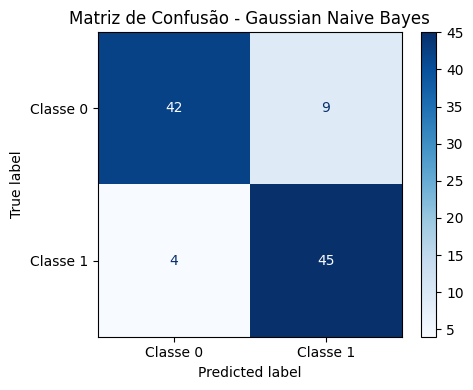

In [6]:
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusão:")
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Classe 0", "Classe 1"]).plot(ax=ax, cmap="Blues")
ax.set_title("Matriz de Confusão - Gaussian Naive Bayes")
plt.tight_layout()
plt.show()

## Curva ROC

AUC: 0.9560


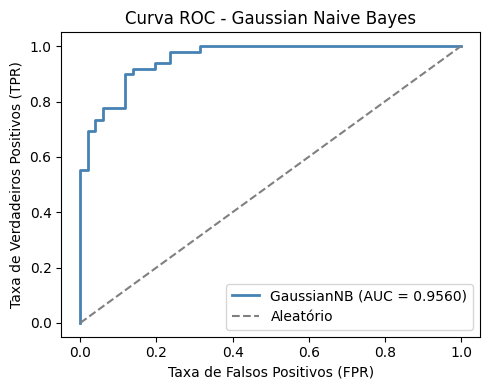

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
print(f"AUC: {auc:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"GaussianNB (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
ax.set_xlabel("Taxa de Falsos Positivos (FPR)")
ax.set_ylabel("Taxa de Verdadeiros Positivos (TPR)")
ax.set_title("Curva ROC - Gaussian Naive Bayes")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Gravar o modelo (arquivo .pkl)

In [8]:
with open("modelo_01_gaussiannb.pkl", "wb") as f:
    pickle.dump(model, f)

print("Modelo salvo em modelo_01_gaussiannb.pkl")

Modelo salvo em modelo_01_gaussiannb.pkl
